In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
from ILAMB import ilamblib
import regionmask as rm
import xclimate as xclim

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ET products

In [3]:
def to_yyyymm(time) -> str:
    time_raw = time.values
    if isinstance(time_raw, np.datetime64):
        return pd.Timestamp(time_raw).strftime("%Y%m")
    elif isinstance(time_raw, np.ndarray):
        return time.item().strftime("%Y%m")
    raise TypeError(f"Unsupported type {type(time)!r} for time")

In [4]:
OBS_PRODUCTS = [
    "FLUXCOM",
    "DOLCE",
    "CLASS",
    # "WECANN",
    "GLEAMv3.3a",
    "MODIS",
    "MOD16A2",
]
ROOT = Path("/glade/campaign/univ/uwas0155/obs/ilamb")

In [5]:
# Load the land mask from the Natural Earth dataset
land = rm.defined_regions.natural_earth_v5_1_2.land_50

et_obs = {}
area = {}
la = {}

for p in OBS_PRODUCTS:
    ds = xr.open_dataset(ROOT / "et" / f"et_{p}.nc")

    if p == "WECANN":
        ds = ds.sortby("lat", ascending=True)  # flip the lat dimension for WECANN

    et_obs[p] = ds["et"]
    print(f"{p:11}: {et_obs[p].dims} {et_obs[p].shape} {to_yyyymm(et_obs[p].time[0])}-{to_yyyymm(et_obs[p].time[-1])}", end=" ")

    if "lat_bounds" in ds and "lon_bounds" in ds:
        print("using bounds")
        method = "bounds"
        lat_bounds = ds["lat_bounds"].values
        lon_bounds = ds["lon_bounds"].values
    else:
        print("could not find bounds, using coordinates instead")
        method = "coords"
        lat_bounds = None
        lon_bounds = None

    # Compute the cell areas using the ILAMB function
    area[p] = ilamblib.CellAreas(
        lat=ds["lat"].values,
        lon=ds["lon"].values,
        lat_bnds=lat_bounds,
        lon_bnds=lon_bounds,
    )

    area[p] = xr.DataArray(area[p], dims=["lat", "lon"], coords={"lat": ds["lat"], "lon": ds["lon"]})
    area[p].attrs["units"] = "m2"
    area[p].attrs["long_name"] = "grid cell area"
    area[p].attrs["method"] = method
    
    # Create a land mask for the dataset using the Natural Earth land mask
    mask = xr.where(np.isnan(land.mask(lon_or_obj=area[p].lon, lat=area[p].lat)), 0, 1)
    la[p] = area[p] * mask
    la[p].attrs["units"] = "m2"
    la[p].attrs["long_name"] = "land grid cell area"
    la[p].attrs["method"] = method

FLUXCOM    : ('time', 'lat', 'lon') (420, 360, 720) 198001-201412 using bounds
DOLCE      : ('time', 'lat', 'lon') (120, 360, 720) 200001-200912 could not find bounds, using coordinates instead
CLASS      : ('time', 'lat', 'lon') (84, 360, 720) 200301-200912 could not find bounds, using coordinates instead
GLEAMv3.3a : ('time', 'lat', 'lon') (468, 360, 720) 198001-201812 using bounds
MODIS      : ('time', 'lat', 'lon') (168, 360, 720) 200001-201312 could not find bounds, using coordinates instead
MOD16A2    : ('time', 'lat', 'lon') (180, 360, 720) 200001-201412 using bounds


In [6]:
np.unique(np.diff(area["CLASS"].lat))

array([0.5])

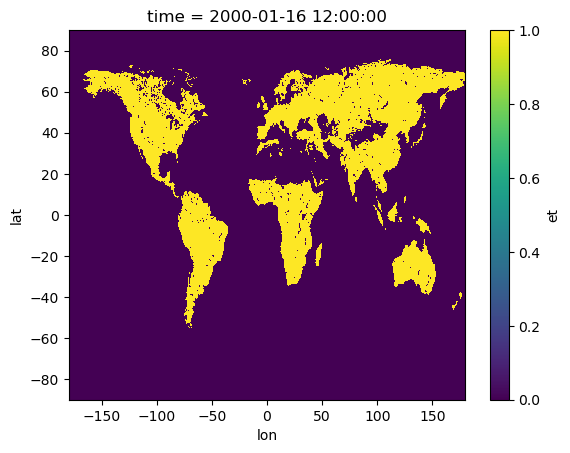

In [70]:
mask = xr.ones_like(et_obs["CLASS"].isel(time=0))

for p in OBS_PRODUCTS:
    mask = xr.where(np.isnan(et_obs[p].isel(time=0)), 0, mask)

mask.plot()

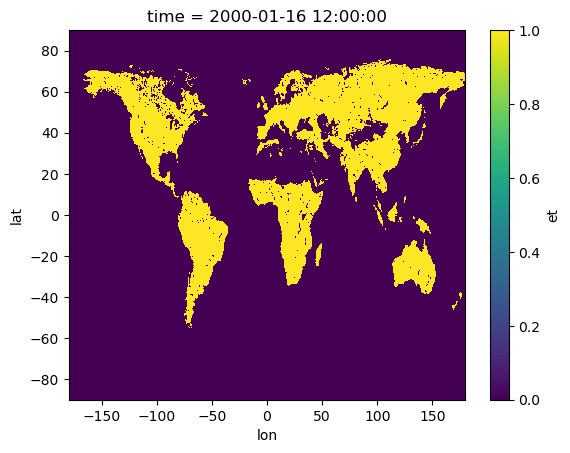

In [71]:
mask.where(la[p]>0, other=0).plot()

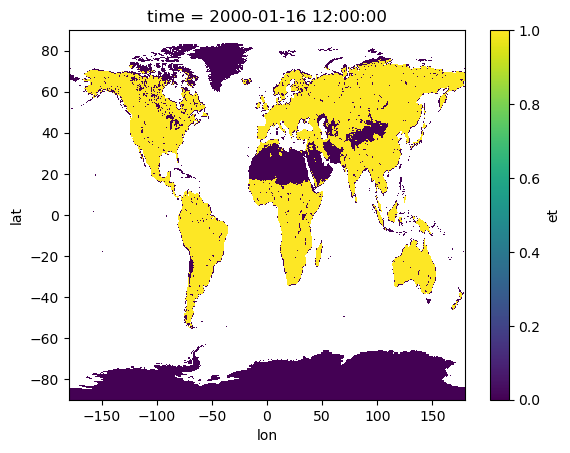

In [73]:
mask.where(mask, other=0).where(la[p]>0).plot()

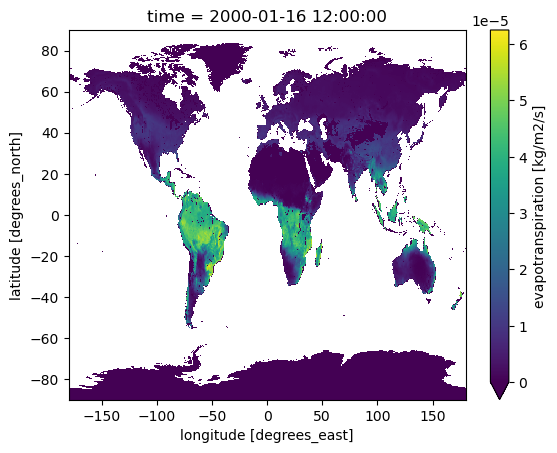

In [74]:
et_obs["MODIS"].isel(time=0).where(mask, other=0).where(la[p]>0).plot(vmin=0)

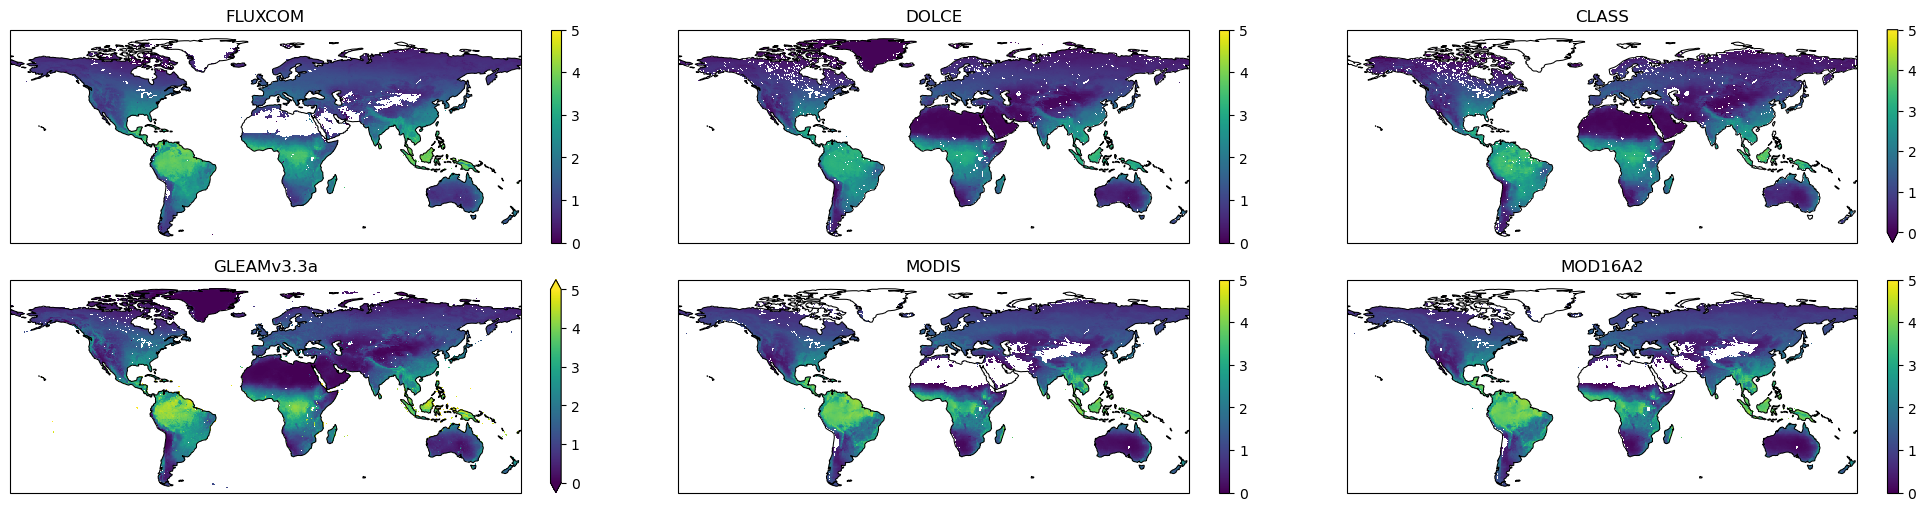

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(20, 5), layout="constrained", subplot_kw={"projection": ccrs.PlateCarree()})
axs = axes.ravel()

for i, p in enumerate(OBS_PRODUCTS):
    (et_obs[p] * 86400).sel(time=slice("2003-01", "2009-12"), lat=slice(-60, 90)).mean(dim="time").plot(ax=axs[i], vmin=0, vmax=5, transform=ccrs.PlateCarree(), add_labels=False)
    axs[i].coastlines(lw=0.75, color="k")
    axs[i].set_title(p)

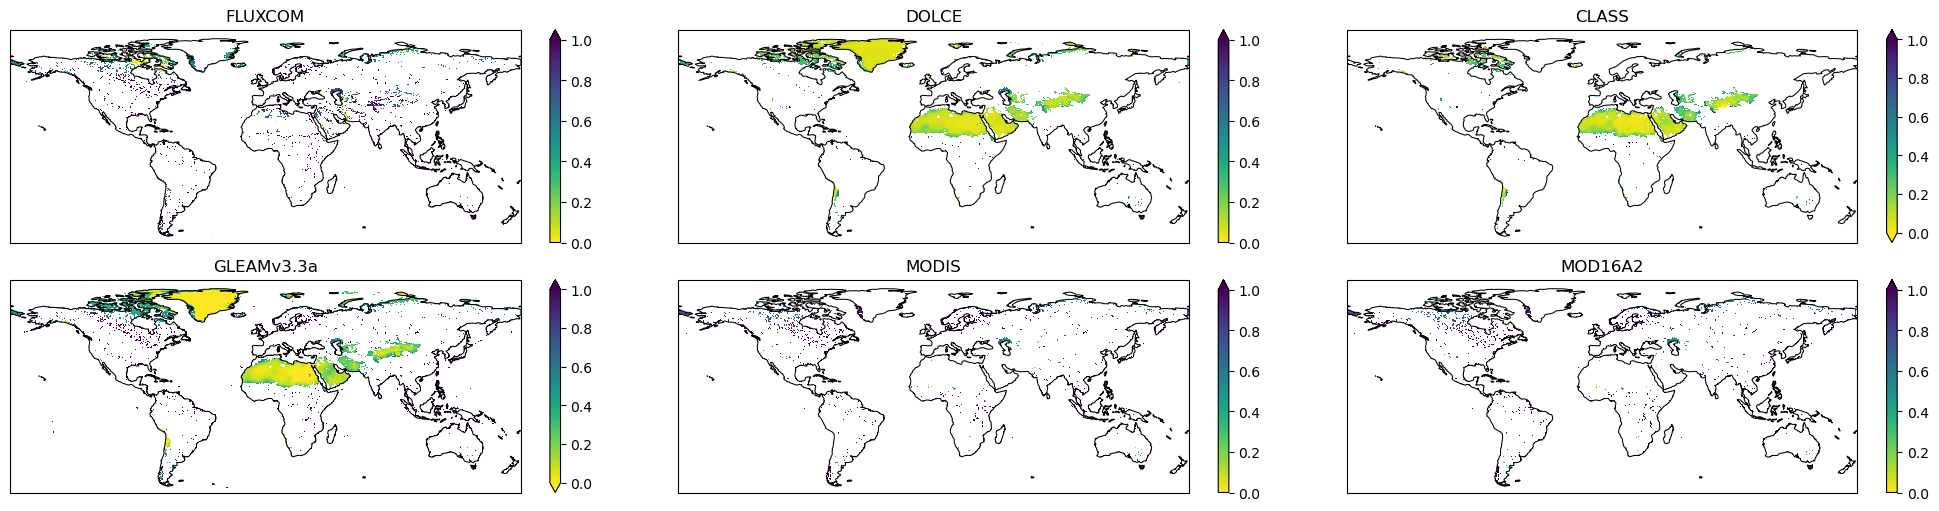

In [82]:
fig, axes = plt.subplots(2, 3, figsize=(20, 5), layout="constrained", subplot_kw={"projection": ccrs.PlateCarree()})
axs = axes.ravel()

for i, p in enumerate(OBS_PRODUCTS):
    (et_obs[p] * 86400).where(mask  == 0).sel(time=slice("2003-01", "2009-12"), lat=slice(-60, 90)).mean(dim="time").plot(ax=axs[i], vmin=0, vmax=1, cmap="viridis_r", transform=ccrs.PlateCarree(), add_labels=False)
    axs[i].coastlines(lw=0.75, color="k")
    axs[i].set_title(p)

In [80]:
print(f"{'name':10}: {'x_raw':6}  {'x_flt1':6}  {'x_flt2':6}  {'x_flt3':6}  {'x_nan':6}")

xs_raw = []
xs_filt1 = []
xs_filt2 = []
xs_filt3 = []

for i, p in enumerate(OBS_PRODUCTS):
    x_raw = (et_obs[p] * 2.5e6).sel(lat=slice(-60, 90), time=slice("2003-01", "2009-12")).mean(dim="time").weighted(la[p]).mean(dim=["lon", "lat"])
    x_filt1 = (et_obs[p] * 2.5e6).where(mask).sel(lat=slice(-60, 90), time=slice("2003-01", "2009-12")).mean(dim="time").weighted(la[p]).mean(dim=["lon", "lat"])
    x_filt2 = (et_obs[p] * 2.5e6).where(mask, other=0).sel(lat=slice(-60, 90), time=slice("2003-01", "2009-12")).mean(dim="time").weighted(la[p]).mean(dim=["lon", "lat"])
    x_filt3 = (et_obs[p] * 2.5e6).where(mask, other=0).where(la[p]>0).sel(lat=slice(-60, 90), time=slice("2003-01", "2009-12")).mean(dim="time").weighted(la[p]).mean(dim=["lon", "lat"])
    x_nan = (et_obs[p] * 2.5e6).where(mask==0, other=0).sel(lat=slice(-60, 90), time=slice("2003-01", "2009-12")).mean(dim="time").weighted(la[p]).mean(dim=["lon", "lat"])
    print(f"{p:10}: {x_raw:6.3f}  {x_filt1:6.3f}  {x_filt2:6.3f}  {x_filt3:6.3f}  {x_nan:6.3f}")

    xs_raw.append(x_raw)
    xs_filt1.append(x_filt1)
    xs_filt2.append(x_filt2)
    xs_filt3.append(x_filt3)

xs_raw = np.array(xs_raw)
xs_filt1 = np.array(xs_filt1)
xs_filt2 = np.array(xs_filt2)
xs_filt3 = np.array(xs_filt3)

print(f"\n{'mean':10}: {xs_raw.mean():0.3f}  {xs_filt1.mean():0.3f}  {xs_filt2.mean():0.3f}  {xs_filt3.mean():0.3f}")
print(f"{'range':10}: {xs_raw.max() - xs_raw.min():0.3f}  {xs_filt1.max() - xs_filt1.min():0.3f}  {xs_filt2.max() - xs_filt2.min():0.3f}  {xs_filt3.max() - xs_filt3.min():0.3f}")
print(f"{'std':10}: {xs_raw.std():0.3f}  {xs_filt1.std():0.3f}  {xs_filt2.std():0.3f}  {xs_filt3.std():0.3f}")

name      : x_raw   x_flt1  x_flt2  x_flt3  x_nan 
FLUXCOM   : 48.833  49.568  37.622  37.622   5.790
DOLCE     : 35.161  41.045  31.153  31.153   1.882
CLASS     : 36.319  41.713  31.660  31.660   0.760
GLEAMv3.3a: 42.104  47.781  36.265  36.265   5.346
MODIS     : 45.013  44.047  33.431  33.431   5.013
MOD16A2   : 45.046  44.080  33.456  33.456   5.017

mean      : 42.079  44.705  33.931  33.931
range     : 13.672  8.523  6.469  6.469
std       : 4.900  3.063  2.325  2.325


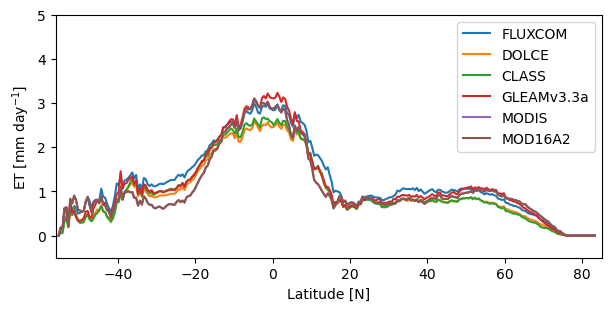

: 

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")

for i, p in enumerate(OBS_PRODUCTS):
    (et_obs[p] * 86400).where(mask, other=0).where(la[p]>0).sel(time=slice("2003-01", "2009-12")).mean(dim=["time", "lon"]).plot(ax=ax, label=p)

ax.set_xlim(-56, 85)
ax.set_ylim(-0.5, 5)
ax.set_xlabel("Latitude [N]")
ax.set_ylabel("ET [mm day$^{-1}$]")
ax.legend()

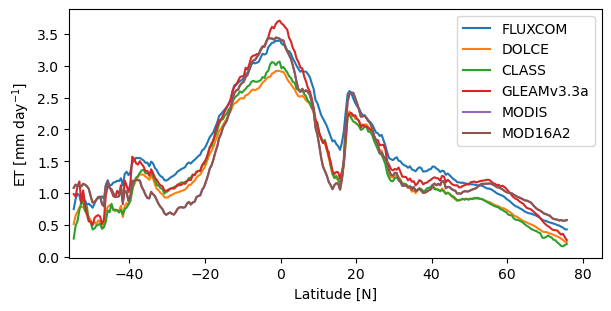

In [51]:
fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")

for i, p in enumerate(OBS_PRODUCTS):
    (et_obs[p] * 86400).where(mask).sel(time=slice("2003-01", "2009-12")).mean(dim=["time", "lon"]).plot(ax=ax, label=p)

ax.set_xlim(-56, 85)
ax.set_xlabel("Latitude [N]")
ax.set_ylabel("ET [mm day$^{-1}$]")
ax.legend()

# ERA5 aridity

In [3]:
def compute_annual_mean(da):
    days_in_month = da.time.dt.days_in_month
    weights = days_in_month.groupby('time.year') / days_in_month.groupby('time.year').sum()
    with xr.set_options(keep_attrs=True):
        return (da * weights).groupby('time.year').sum()


def compute_aridity_index(
    precip: xr.DataArray,
    pet: xr.DataArray,
    clip: bool = False,
) -> xr.DataArray:
    """Compute the annual mean aridity index."""
    if clip:
        pet = pet.clip(min=0)
    ai = precip / pet
    ai = ai.rename("AI")
    ai.attrs = {
        "long_name": "aridity index (P/PET)",
        "description": "computed from annual mean P and PET{' (PET floor at zero)' if clip else ''}",
    }
    return ai


def compute_inverse_aridity_index(
    precip: xr.DataArray,
    pet: xr.DataArray,
    clip: bool = False,
) -> xr.DataArray:
    """Compute the annual mean inverse aridity index."""
    if clip:
        pet = pet.clip(min=0)
    inv_ai = pet / precip
    inv_ai = inv_ai.rename("AI")
    inv_ai.attrs = {
        "long_name": "inverse aridity index (PET/P)",
        "description": f"computed from annual mean P and PET{' (PET floor at zero)' if clip else ''}",
    }
    return inv_ai

In [ ]:
era_grid = xclim.load_era5_grid()

era = {}
era_ann = {}
for v in ["msnswrf", "msnlwrf", "mtpr", "mer"]:
    era[v] = xclim.load_era5(v, "1995-01", "2014-12", kind="meanflux")[v.upper()].where(era_grid.LANDFRAC > 0.50).chunk({"lat": -1, "lon": -1})
    era_ann[v] = compute_annual_mean(era[v])

In [21]:
era_ann["rn"] = era_ann["msnswrf"] + era_ann["msnlwrf"]

era_ann["mtpr"] = era_ann["mtpr"] * 2.5e6
era_ann["mtpr"].attrs["units"] = "W/m2"

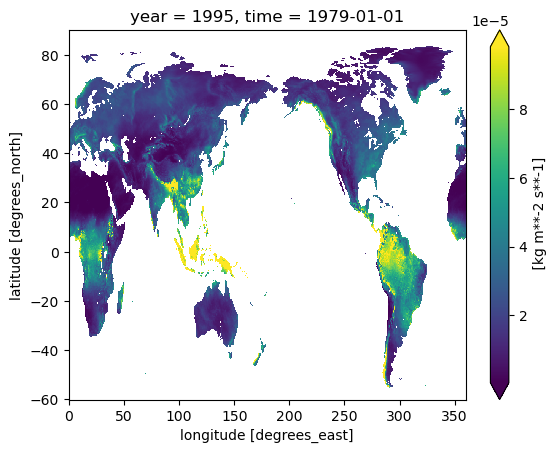

In [13]:
era_ann["mtpr"].isel(year=0).where(era_grid.LANDFRAC > 0.50).sel(lat=slice(90, -60)).plot(robust=True)

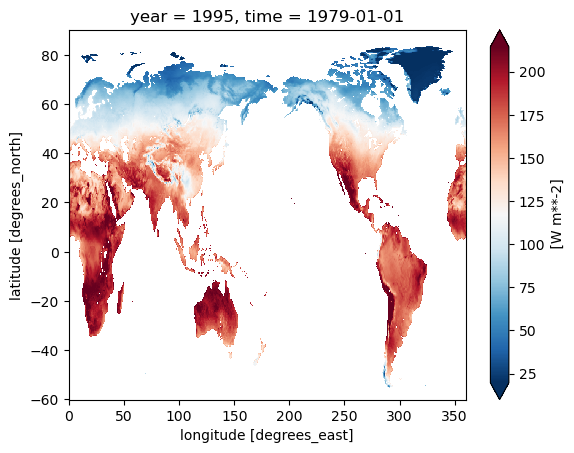

In [19]:
era_ann["msnswrf"].isel(year=0).where(era_grid.LANDFRAC > 0.50).sel(lat=slice(90, -60)).plot(robust=True, cmap="RdBu_r")

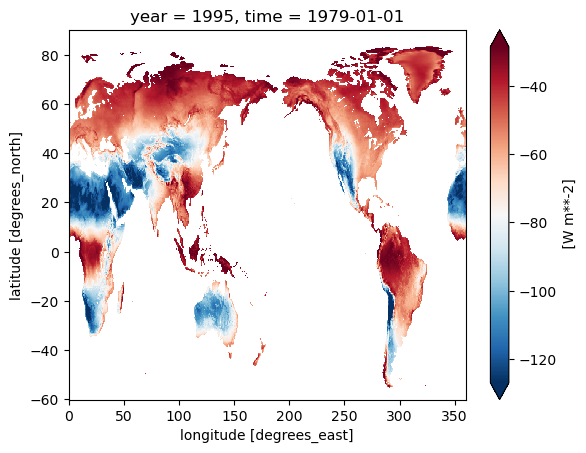

In [17]:
era_ann["msnlwrf"].isel(year=0).where(era_grid.LANDFRAC > 0.50).sel(lat=slice(90, -60)).plot(robust=True, cmap="RdBu_r")

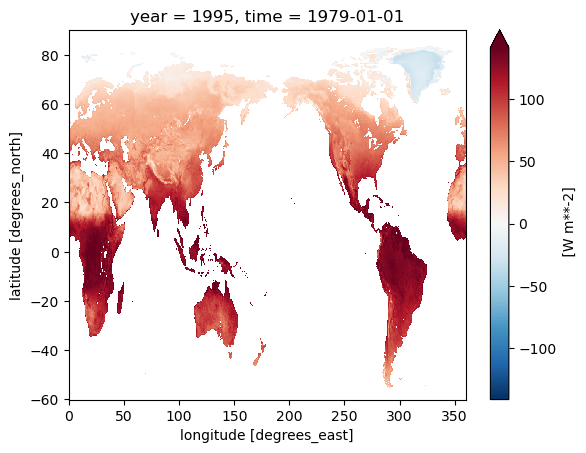

In [22]:
era_ann["rn"].isel(year=0).where(era_grid.LANDFRAC > 0.50).sel(lat=slice(90, -60)).plot(robust=True)

In [26]:
era_ai = compute_aridity_index(era_ann["mtpr"].mean(dim="year"), era_ann["rn"].mean(dim="year")).compute()
era_ai_inv = compute_inverse_aridity_index(era_ann["mtpr"].mean(dim="year"), era_ann["rn"].mean(dim="year")).compute()

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


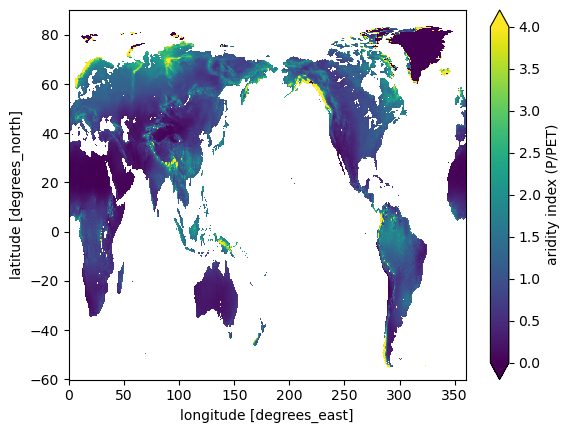

In [39]:
era_ai.sel(lat=slice(90, -60)).plot(vmin=0, vmax=4)

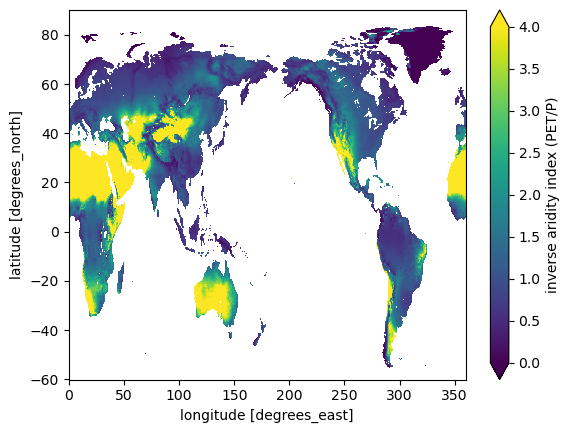

In [40]:
era_ai_inv.sel(lat=slice(90, -60)).plot(vmin=0, vmax=4)

In [ ]:
era_ai_qnt = era_ai.sel(lat=slice(90, -60)).stack(z=["lat", "lon"]).quantile(np.linspace(0, 1, 100))
era_ai_inv_qnt = era_ai_inv.sel(lat=slice(90, -60)).stack(z=["lat", "lon"]).quantile(np.linspace(0, 1, 100))

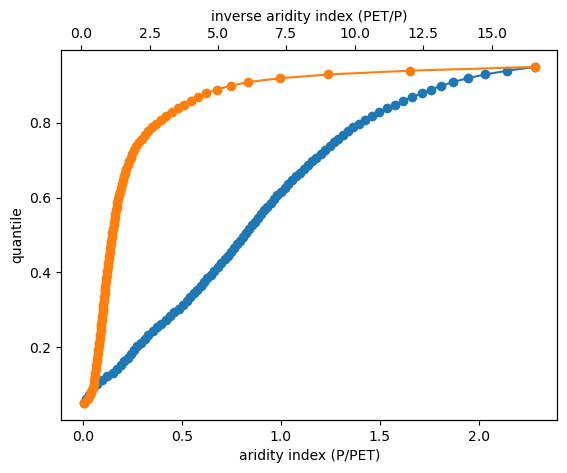

In [45]:
fig, ax = plt.subplots()
era_ai_qnt[5:-5].plot(ax=ax, marker="o", y="quantile")

ax2 = ax.twiny()
era_ai_inv_qnt[5:-5].plot(ax=ax2, color="tab:orange", marker="o", y="quantile")

# Trends

In [2]:
fluxcom_reg_trends = xr.open_dataset("/glade/work/bbuchovecky/et_unc/obs/et/trends/et_FLUXCOM_year_dsc_giorgi_regions_ols_stats_198001-201412.nc")